In [456]:
import torch
from torch.distributions import Dirichlet, Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpltern
import numpy as np
import pandas as pd

# Create synthetic classification dataset

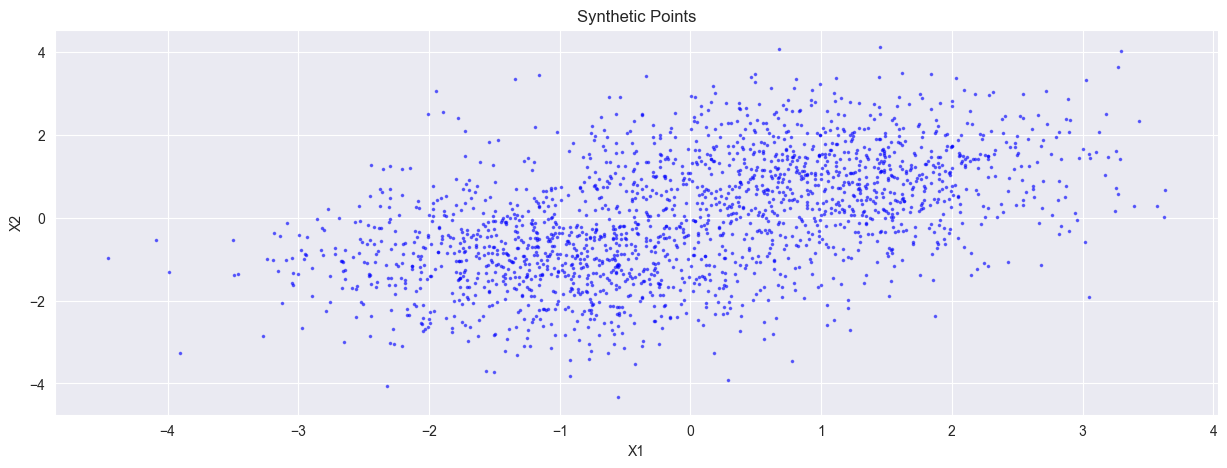

In [457]:
def generate_x_points(n_samples=1000,bias=1):
    """
    Generate n_samples points in the simplex.
    """
    # Generate random points in the simplex
    x1_corr = Normal(0, 1).sample((n_samples,))
    x2_corr = Normal(0, 1).sample((n_samples,))
    points = torch.stack([x1_corr, x2_corr], dim=1).numpy() + bias
    return points

# visualize the points
def visualize_points(points):
    """
    Visualize the points in the simplex.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    ax.scatter(points[:,0], points[:,1], marker='.', s=10, alpha=0.5, color='blue')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.show()

# Generate points
point_bunch = generate_x_points(bias=-1)
point_bunch2 = generate_x_points(bias=1)
points = np.concatenate((point_bunch,point_bunch2),axis=0)
# Visualize points
visualize_points(points)

# Define True Target Probability Distribution

In [458]:
# define 1st order probability distribution

def generate_y_probs(points):
    probs = 1 / (1+ torch.exp(
        - (points[:,0]**2 - 1)
    ))
    y_probs = torch.stack([1-probs, probs], dim=-1)
    return y_probs.clip(1e-8,(9999999)/1e7)

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(torch.tensor(points))
y_probs

tensor([[0.7183, 0.2817],
        [0.6625, 0.3375],
        [0.4702, 0.5298],
        ...,
        [0.6491, 0.3509],
        [0.4510, 0.5490],
        [0.6622, 0.3378]])

# Define Ensemble

In [459]:
ENSEMBLE_MEMBER_COUNT = 10


# define (mimic) ensemble
def noisy_probability(points,generator):
    y_probs = generate_y_probs(points)
    noise = 0.001*torch.randn(y_probs.size(),
                        generator=generator,
                        dtype=y_probs.dtype,
                        layout=y_probs.layout,
                        device=y_probs.device)
    y_probs_noisy = torch.logit(y_probs).add(noise).softmax(dim=-1)
    return y_probs_noisy
def ensemble_probs(points):
    y_probs_ensemble = torch.stack([noisy_probability(points,
                                                      torch.Generator().manual_seed(i)
                                                      ) for i in range(ENSEMBLE_MEMBER_COUNT)])
    return y_probs_ensemble

def ensemble_preditions(points):
    y_probs_ensemble = ensemble_probs(points)
    return y_probs_ensemble.mean(dim=0).argmax(dim=1)
y_probs_ensemble_points = ensemble_probs(torch.tensor(points))
y_pred_ensemble_points = ensemble_preditions(torch.tensor(points))
y_pred_ensemble_points
ensemble_probs(torch.tensor([[10,10]]))

tensor([[[1.1943e-15, 1.0000e+00]],

        [[1.1926e-15, 1.0000e+00]],

        [[1.1928e-15, 1.0000e+00]],

        [[1.1928e-15, 1.0000e+00]],

        [[1.1899e-15, 1.0000e+00]],

        [[1.1922e-15, 1.0000e+00]],

        [[1.1910e-15, 1.0000e+00]],

        [[1.1910e-15, 1.0000e+00]],

        [[1.1939e-15, 1.0000e+00]],

        [[1.1899e-15, 1.0000e+00]]])

In [460]:
def total_uncertainty_ensemble(y_probs_ensemble):
    y_probs_mean = y_probs_ensemble.mean(dim=0)
    return y_probs_mean.mul(y_probs_mean.log2()).sum(dim=-1).mul(-1)

def aleatoric_uncertainty_ensemble(y_probs_ensemble):
    return y_probs_ensemble.mul(y_probs_ensemble.log2()).sum(dim=-1).mul(-1).mean(dim=0)

def epistemic_uncertainty_ensemble(y_probs_ensemble):
    return (total_uncertainty_ensemble(y_probs_ensemble) - aleatoric_uncertainty_ensemble(y_probs_ensemble)).clip(0,1)


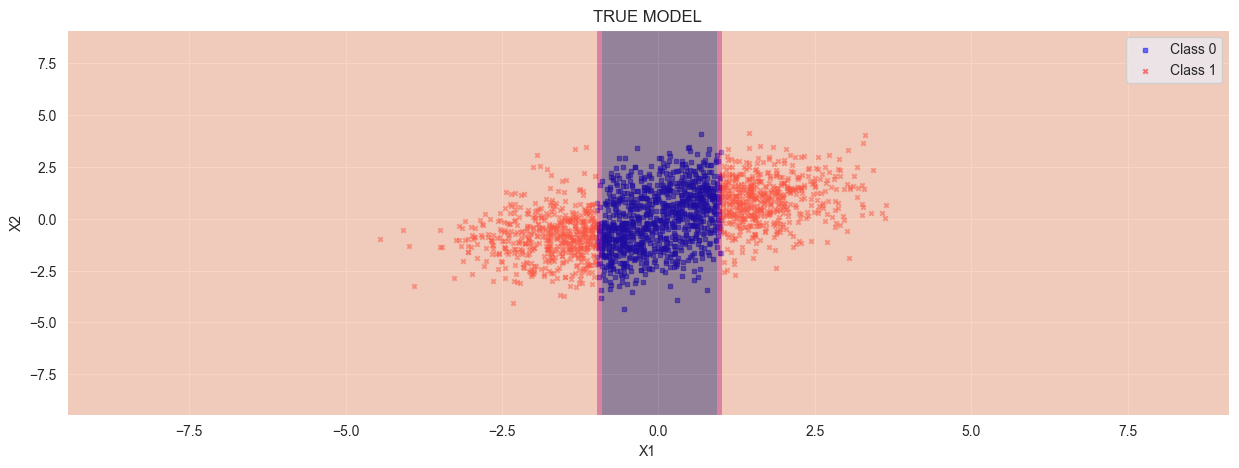

In [461]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(torch.tensor(grid_points))
    gird_y_labels = grid_y_labels.numpy()

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(points,y_labels)

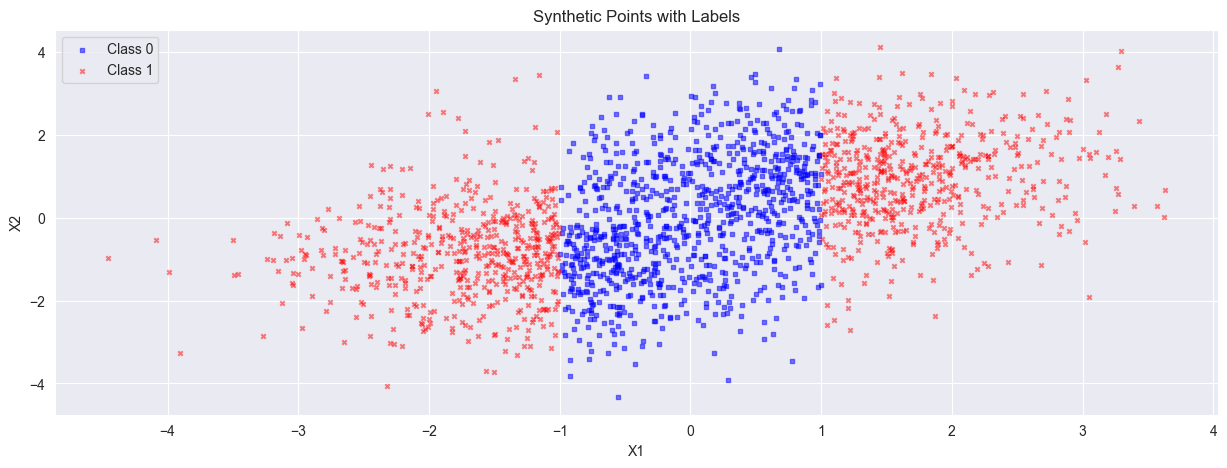

In [462]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(points, y_labels)

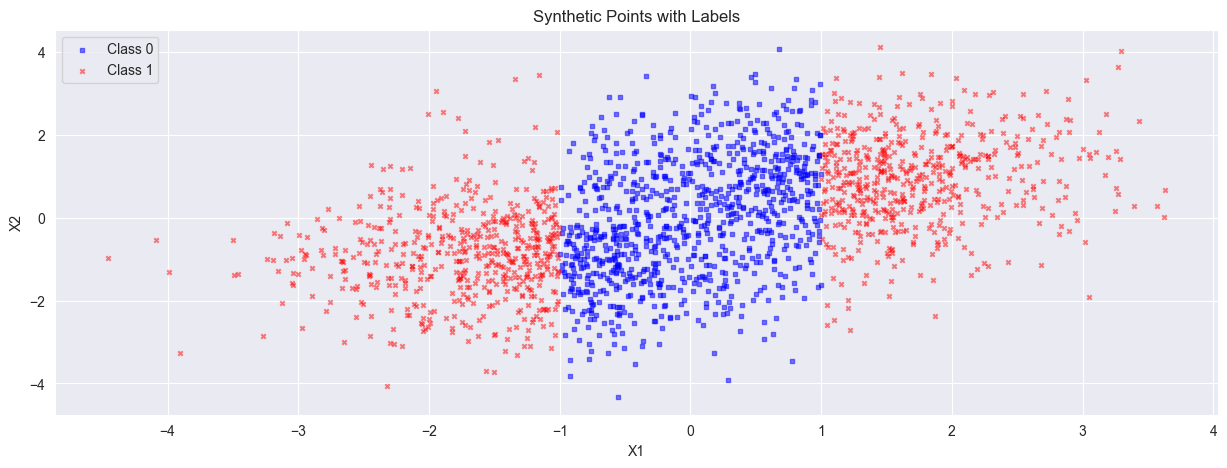

In [463]:
# visualize predictions of the ensemble
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()


# Visualize points and labels
visualize_points_and_labels(points, y_pred_ensemble_points)


tensor(0.) tensor(1.)


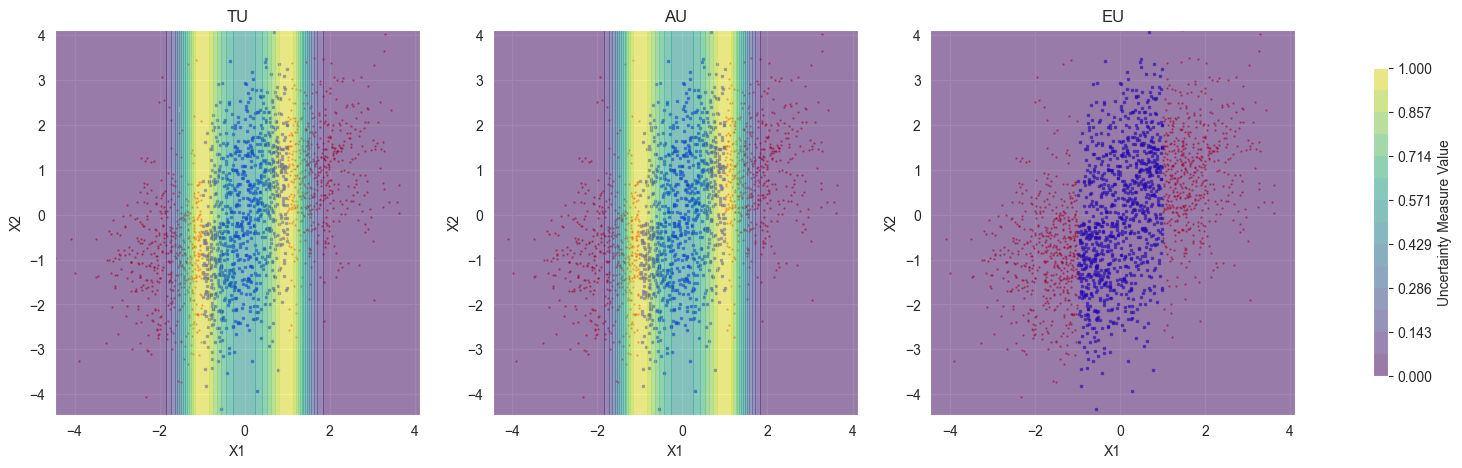

In [464]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    y_probs_ensemble = ensemble_probs(torch.tensor(grid_points))
    total_uncertainty = total_uncertainty_ensemble(y_probs_ensemble)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(y_probs_ensemble)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(y_probs_ensemble)

    # Shared value range
    all_vals = torch.concatenate([total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='.', s=2, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(points,y_pred_ensemble_points)

# CF construction

In [465]:
MAX_STEPS = 1000
UNCERTAINTY_STEP_INCREASE = 1e-2
DESIRED_VALIDITY = 0.9

### Validity
We now work in the scenario of creating a valid counter factual for our point x

In [466]:
point_of_interest = torch.tensor(np.array([0.2,-0.1]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [467]:
def validity_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    # Get the probs in the start
    probs = ensemble_probs(counter_factual).mean(dim=0)
    target_probs = probs[0,desired_class]
    # Optimization Iteration
    while target_probs < desired_validity:
        optimizer.zero_grad()

        # Extract loss value
        probs = ensemble_probs(counter_factual).mean(dim=0)
        target_probs = probs[0,desired_class]
        # Calculate the loss
        loss = -target_probs
        #print(target_probs)
        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
    return counter_factual.detach(), counter_factual_steps

cf_valid, cf_steps_valid = validity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

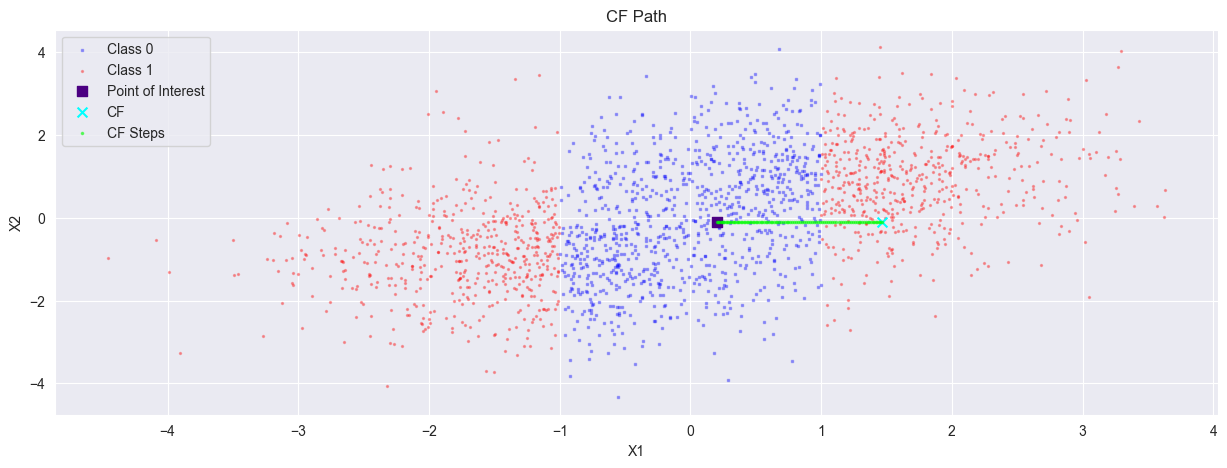

In [468]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.3, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='o', s=2, alpha=0.3, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=50, alpha=1, color='indigo', label="Point of Interest")

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=50, color='aqua', label="CF")

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='lime', label="CF Steps")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")

    plt.legend()
visualize_cf_and_steps(cf_valid, cf_steps_valid, points, y_labels)

## Plausability

In [469]:
def plausability_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        # Calculate the loss
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        loss = (-target_probs).add(t*eu)

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_plausable, cf_steps_plausable = plausability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

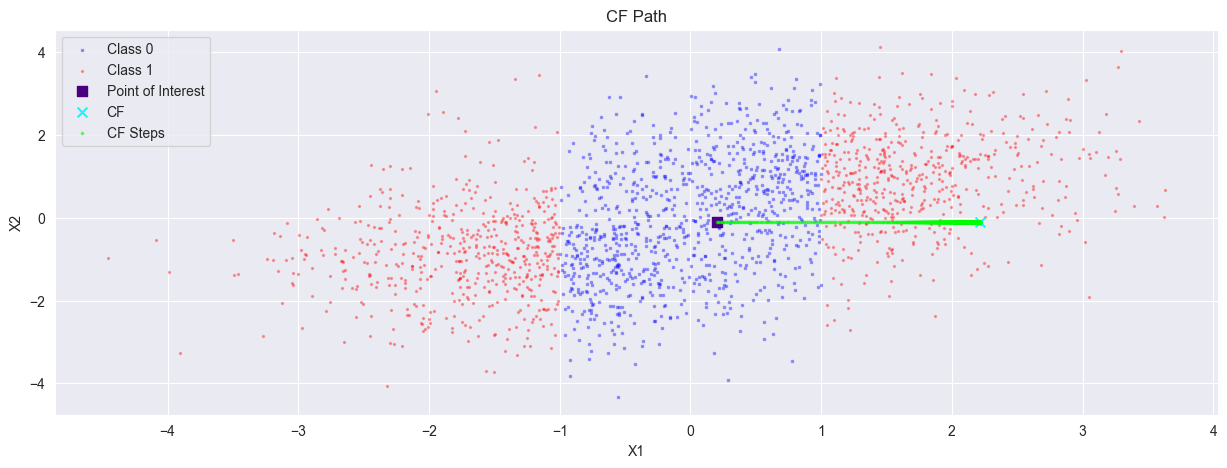

In [470]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, points, y_pred_ensemble_points)

In [471]:
cf_plausable, cf_valid

(tensor([[ 2.2177, -0.1000]]), tensor([[ 1.4632, -0.1000]]))

In [472]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable)), epistemic_uncertainty_ensemble(ensemble_probs(cf_valid))

(tensor([3.4459e-08]), tensor([8.9407e-08]))

## Discrimitiveness

In [473]:
def discriminiative_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual,au, t)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_discriminiative, cf_steps_discriminiative = discriminiative_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

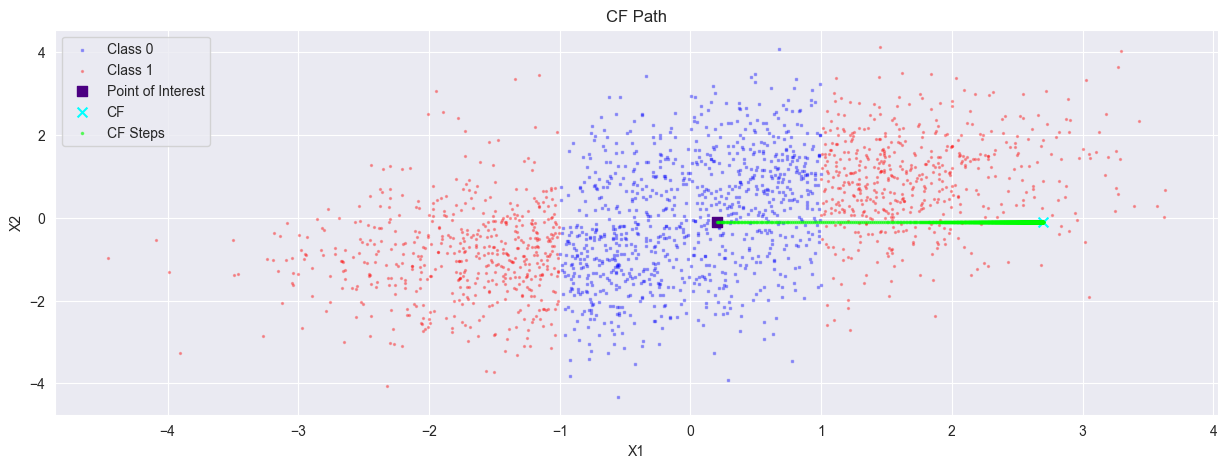

In [474]:
visualize_cf_and_steps(cf_discriminiative, cf_steps_discriminiative, points, y_pred_ensemble_points)


In [475]:
cf_discriminiative, cf_plausable, cf_valid

(tensor([[ 2.6983, -0.1000]]),
 tensor([[ 2.2177, -0.1000]]),
 tensor([[ 1.4632, -0.1000]]))

In [476]:
aleatoric_uncertainty_ensemble(ensemble_probs(cf_plausable)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_valid)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_discriminiative))


(tensor([0.0050]), tensor([0.4452]), tensor([6.8503e-05]))

## Stability

In [477]:
def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)
        delta_sample = sample  * delta
        delta_samples.append([delta_sample])
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples, requires_grad=True)

In [478]:
def stable_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points).view(-1,2)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = torch.std(
            input=torch.cat(((-target_probs).add(t*au) , (-target_probs_delta_ball).add(t*au_delta_ball)))
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
       # print(counter_factual,eu, t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_stable, cf_steps_stable = stable_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

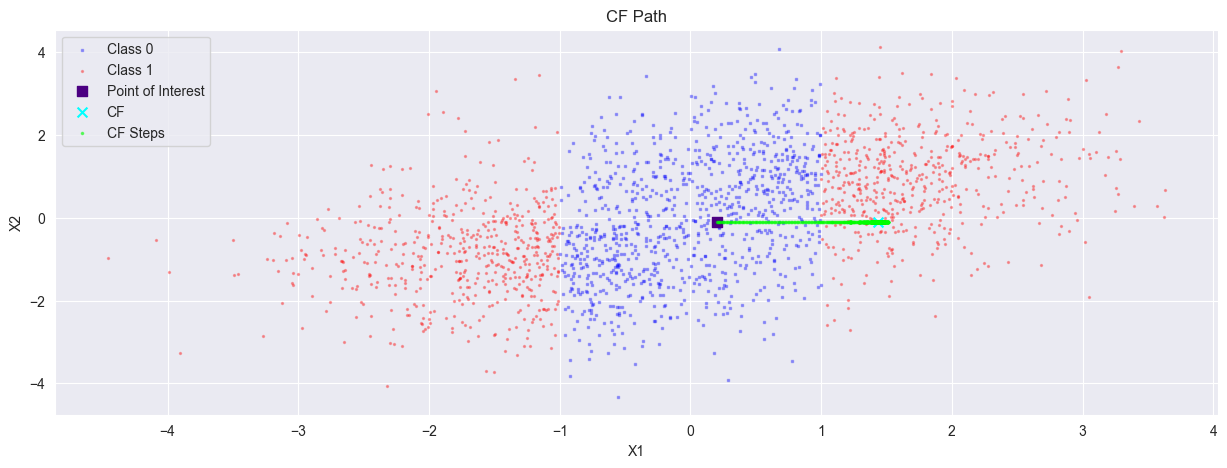

In [479]:
visualize_cf_and_steps(cf_stable,cf_steps_stable, points, y_pred_ensemble_points)

In [480]:
# delta_point_of_interest = sample_delta_ball(point_of_interest.detach().numpy(), delta=1, n_points=10)
# cf_points_stable = []
# for point in delta_point_of_interest:
#     cf_point, cf_steps_point = stable_procedure(point.view(-1,2), desired_validity=0.9, delta=1, n_points=10)
#     #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
#     cf_points_stable.append(cf_point)
#
# # compare with validitiy procedure
# cf_points_not_stable =[]
# for point in delta_point_of_interest:
#     cf_point, cf_steps_point = validity_procedure(point.view(-1,2), desired_validity=0.9)
#     #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
#     cf_points_not_stable.append(cf_point)
#
#
# # compute the mean l2 distance for stable and not stable
# l2_distances_stable = [
#     torch.norm(p1 - p2, p=2).item()
#     for p1 in cf_points_stable
#     for p2 in cf_points_stable
#     if (p1 != p2).all()
# ]
# l2_distances_unstable = [
#     torch.norm(p1 - p2, p=2).item()
#     for p1 in cf_points_not_stable
#     for p2 in cf_points_not_stable
#     if (p1 != p2).all()
# ]
#
# print("Mean L2-Distance of Stable Procedure: ", np.mean(l2_distances_stable), " +/- ",  np.std(l2_distances_stable))
# print("Mean L2-Distance of Unstable Procedure: ", np.mean(l2_distances_unstable), " +/- ",  np.std(l2_distances_unstable))

## Robustness

tensor(0., grad_fn=<MinBackward1>) tensor(4.9309e-07, grad_fn=<MaxBackward1>)


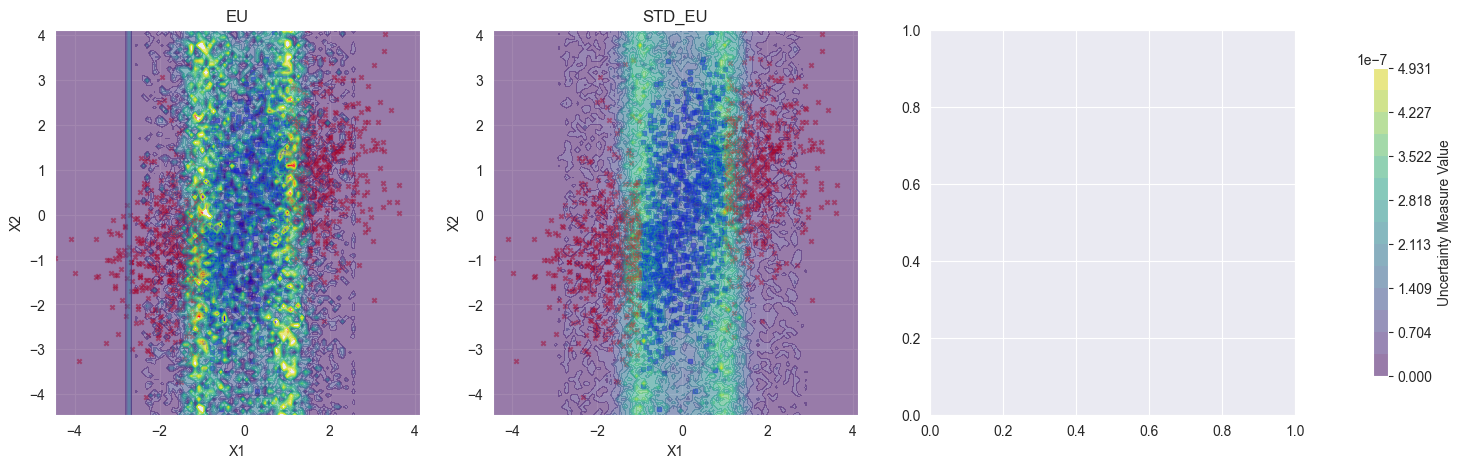

In [481]:
# visualize how std of eu looks like aroung the points
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),0.2,10)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).view(10,-1)


    std_eu_ball = torch.mean(torch.cat((eu_delta_ball,epistemic_uncertainty.view(1,-1))),dim=0)

    # Shared value range
    all_vals = torch.concatenate([std_eu_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [epistemic_uncertainty, std_eu_ball], ["EU","STD_EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(points,y_pred_ensemble_points)

In [482]:
def robust_procedure(point_to_explain, desired_validity=0.8, delta=0.2, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points).view(-1,2)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]

        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        std_eu_ball = torch.std(
            eu_delta_ball
        )**2
        mean_eu_ball = torch.mean(
            eu_delta_ball
        )
        # Calculate the loss
        loss = (-target_probs + (t*std_eu_ball))

        # Backpropagate
        loss.backward()
        optimizer.step()
        print(counter_factual,eu,std_eu_ball,mean_eu_ball, t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_robust, cf_steps_robust = robust_procedure(point_of_interest,delta=0.5)

tensor([[ 0.2100, -0.1000]], requires_grad=True) tensor([1.1921e-07], grad_fn=<ClampBackward1>) tensor(6.4738e-15, grad_fn=<PowBackward0>) tensor(1.4305e-07, grad_fn=<MeanBackward0>) 0 0
tensor([[ 0.2200, -0.1000]], requires_grad=True) tensor([1.1921e-07], grad_fn=<ClampBackward1>) tensor(4.8949e-15, grad_fn=<PowBackward0>) tensor(9.5367e-08, grad_fn=<MeanBackward0>) 0 1
tensor([[ 0.2300, -0.1000]], requires_grad=True) tensor([1.1921e-07], grad_fn=<ClampBackward1>) tensor(1.0619e-14, grad_fn=<PowBackward0>) tensor(1.2517e-07, grad_fn=<MeanBackward0>) 0 2
tensor([[ 0.2401, -0.1000]], requires_grad=True) tensor([1.1921e-07], grad_fn=<ClampBackward1>) tensor(6.6712e-15, grad_fn=<PowBackward0>) tensor(1.7285e-07, grad_fn=<MeanBackward0>) 0 3
tensor([[ 0.2502, -0.1000]], requires_grad=True) tensor([1.7881e-07], grad_fn=<ClampBackward1>) tensor(1.3263e-14, grad_fn=<PowBackward0>) tensor(1.9073e-07, grad_fn=<MeanBackward0>) 0 4
tensor([[ 0.2603, -0.1000]], requires_grad=True) tensor([0.], gra

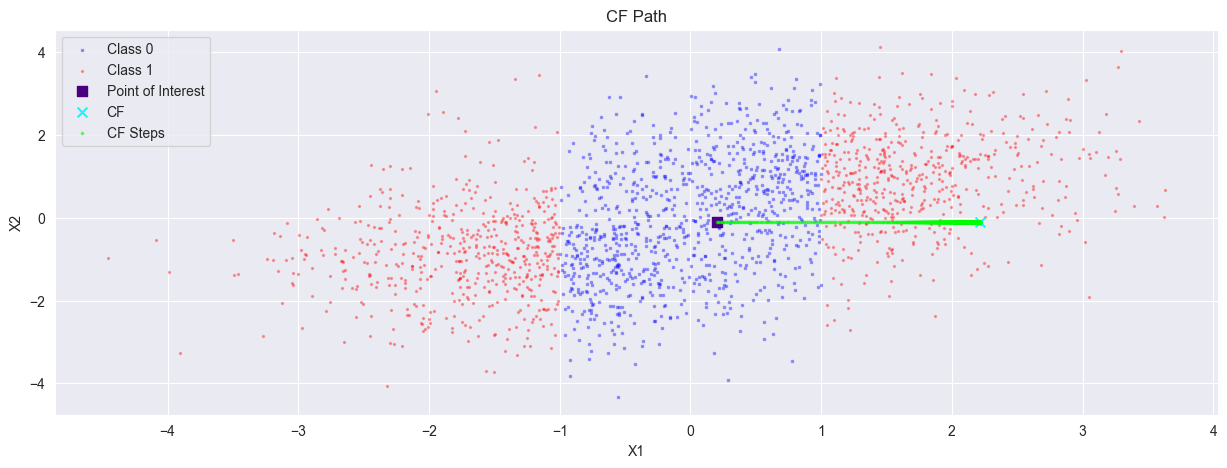

In [483]:
visualize_cf_and_steps(cf_robust,cf_steps_robust, points, y_pred_ensemble_points)

In [484]:
cf_robust, cf_plausable

(tensor([[ 2.2177, -0.1000]]), tensor([[ 2.2177, -0.1000]]))

In [485]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_robust)), epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable))

(tensor([3.4925e-08]), tensor([3.4459e-08]))

In [486]:

res_mean = []
res_std = []
for _ in range(10):
    delta_cf_robust = sample_delta_ball(cf_robust.detach().numpy(), delta=1, n_points=100)
    epistemic_cf_robust = []
    for point in delta_cf_robust:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_robust.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    delta_cf_plausable = sample_delta_ball(cf_plausable.detach().numpy(), delta=1, n_points=100)
    epistemic_cf_plausable = []
    for point in delta_cf_plausable:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_plausable.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    print("Std Epistemic Uncertainty of Robust Procedure: ",np.mean(epistemic_cf_robust) , " +/- " ,  np.std(epistemic_cf_robust))
    print("Std Epistemic Uncertainty of Plausable Procedure: ", np.mean(epistemic_cf_plausable) , " +/- " , np.std(epistemic_cf_plausable))

    res_mean.append([np.mean(epistemic_cf_robust), np.mean(epistemic_cf_plausable)])
    res_std.append([np.std(epistemic_cf_robust), np.std(epistemic_cf_plausable)])

np.mean(res_mean,axis=0), np.std(res_mean,axis=0), np.mean(res_std,axis=0), np.std(res_std,axis=0)

Std Epistemic Uncertainty of Robust Procedure:  5.1012847e-08  +/-  7.8151636e-08
Std Epistemic Uncertainty of Plausable Procedure:  6.5145876e-08  +/-  8.916724e-08
Std Epistemic Uncertainty of Robust Procedure:  4.6513193e-08  +/-  7.121482e-08
Std Epistemic Uncertainty of Plausable Procedure:  6.212097e-08  +/-  8.712251e-08
Std Epistemic Uncertainty of Robust Procedure:  5.3583612e-08  +/-  7.776597e-08
Std Epistemic Uncertainty of Plausable Procedure:  5.2986906e-08  +/-  7.719575e-08
Std Epistemic Uncertainty of Robust Procedure:  5.8764584e-08  +/-  7.702817e-08
Std Epistemic Uncertainty of Plausable Procedure:  4.4726725e-08  +/-  6.180145e-08
Std Epistemic Uncertainty of Robust Procedure:  5.3599734e-08  +/-  8.594375e-08
Std Epistemic Uncertainty of Plausable Procedure:  5.2550366e-08  +/-  8.086691e-08
Std Epistemic Uncertainty of Robust Procedure:  5.157443e-08  +/-  7.8444394e-08
Std Epistemic Uncertainty of Plausable Procedure:  7.791387e-08  +/-  9.090786e-08
Std Epistem

(array([5.2720946e-08, 5.6288116e-08], dtype=float32),
 array([3.5389007e-09, 9.4525356e-09], dtype=float32),
 array([7.7497290e-08, 7.8933404e-08], dtype=float32),
 array([4.4916892e-09, 8.3746432e-09], dtype=float32))

## Connectednss

In [487]:
def sample_line(x1, x2, num_samples=10):
    """
    Returns `num_samples` points along the line from `x1` to `x2`.
    Supports gradients with respect to x1 and x2.

    Args:
        x1 (torch.Tensor): Starting point (shape: [D])
        x2 (torch.Tensor): Ending point (shape: [D])
        num_samples (int): Number of points to sample along the line

    Returns:
        torch.Tensor: Points along the line (shape: [num_samples, D])
    """
    # Ensure inputs are tensors with gradient tracking
    x1 = x1.requires_grad_()
    x2 = x2.requires_grad_()

    # Create interpolation coefficients t in [0, 1]
    t = torch.linspace(0, 1, num_samples, device=x1.device).unsqueeze(1)  # shape: [num_samples, 1]

    # Linear interpolation
    points = (1 - t) * x1 + t * x2  # shape: [num_samples, D]
    return points

In [488]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)


        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = torch.mean(
            au_line
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected, cf_steps_connected = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

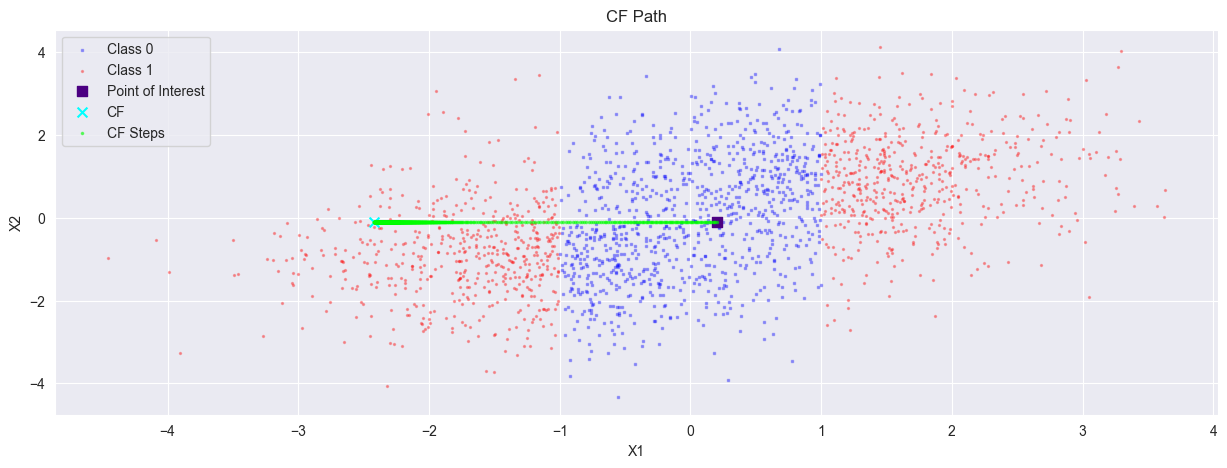

In [489]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, points, y_pred_ensemble_points)

In [490]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = epistemic_uncertainty_ensemble(probs_ensemble)


        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        eu_line = epistemic_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = torch.mean(
            eu_line
        )**2
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected_eu, cf_steps_connected_eu = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

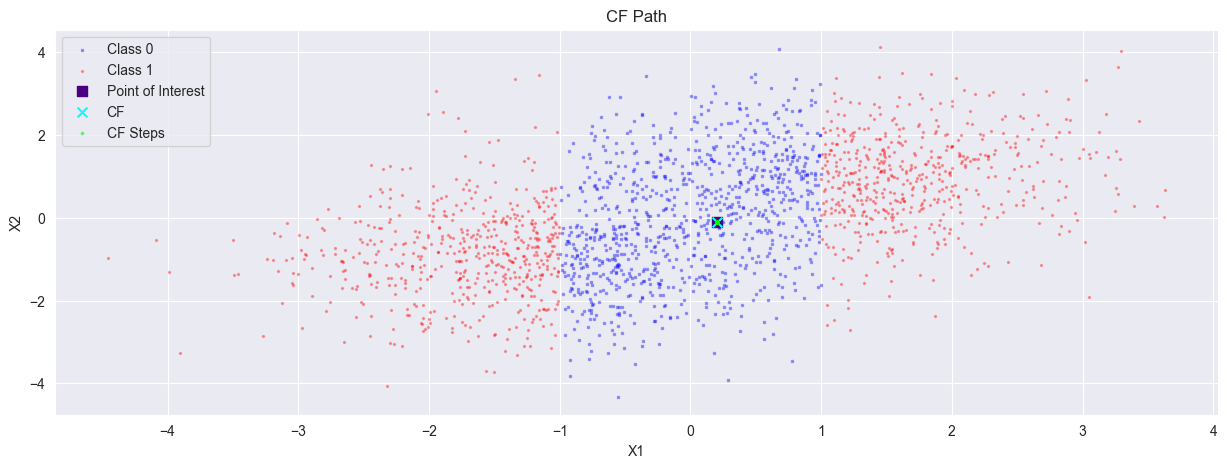

In [491]:
visualize_cf_and_steps(cf_connected_eu,cf_steps_connected_eu, points, y_pred_ensemble_points)

## Similarity

In [492]:
def similiarity_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)



        reference_point = point_to_explain.clone().detach().requires_grad_(True)



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -torch.mean(
            au_line
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_similiar, cf_steps_similiar = similiarity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

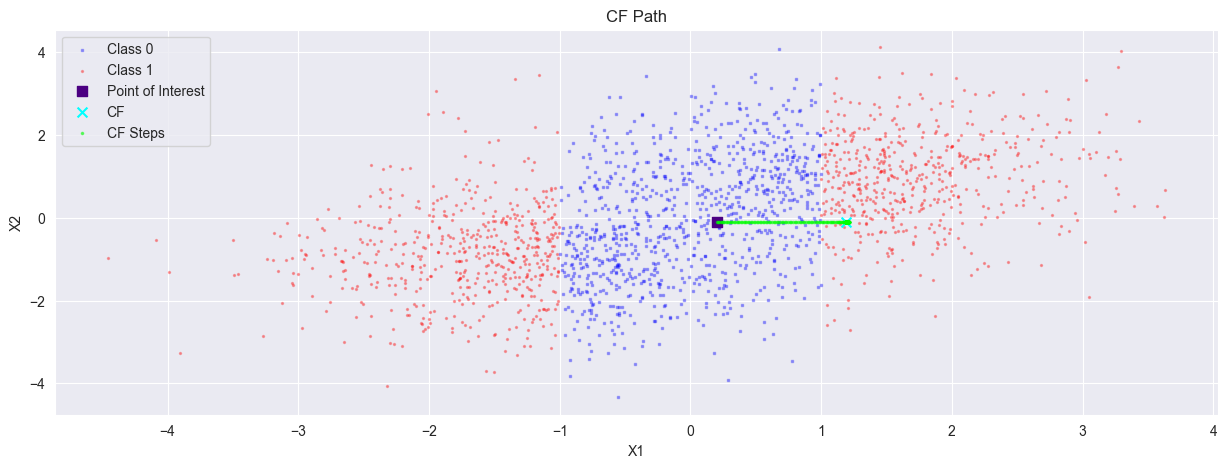

In [493]:
visualize_cf_and_steps(cf_similiar,cf_steps_similiar, points, y_pred_ensemble_points)

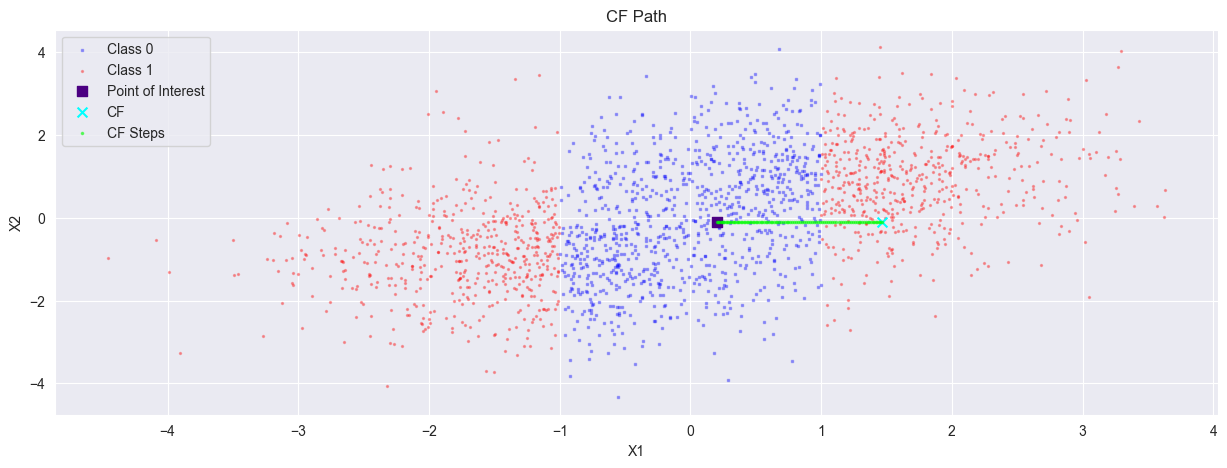

In [494]:
visualize_cf_and_steps(cf_valid,cf_steps_valid, points, y_pred_ensemble_points)

In [495]:
cf_similiar, cf_valid

(tensor([[ 1.1934, -0.1000]]), tensor([[ 1.4632, -0.1000]]))

In [496]:
print(point_of_interest)

tensor([[ 0.2000, -0.1000]], requires_grad=True)


In [497]:
#l2 distance of similiar and valid
torch.linalg.norm(cf_similiar - point_of_interest, ord=2)

tensor(0.9934, grad_fn=<AmaxBackward0>)

In [498]:
torch.linalg.norm(cf_valid - point_of_interest, ord=2)

tensor(1.2632, grad_fn=<AmaxBackward0>)

## Feasability

In [499]:
def feasability_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)

        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])
        #print(reference_point)



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs + 2*torch.mean(
            au_line
        ) + 1.5*eu
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_feasable, cf_steps_feasable = feasability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

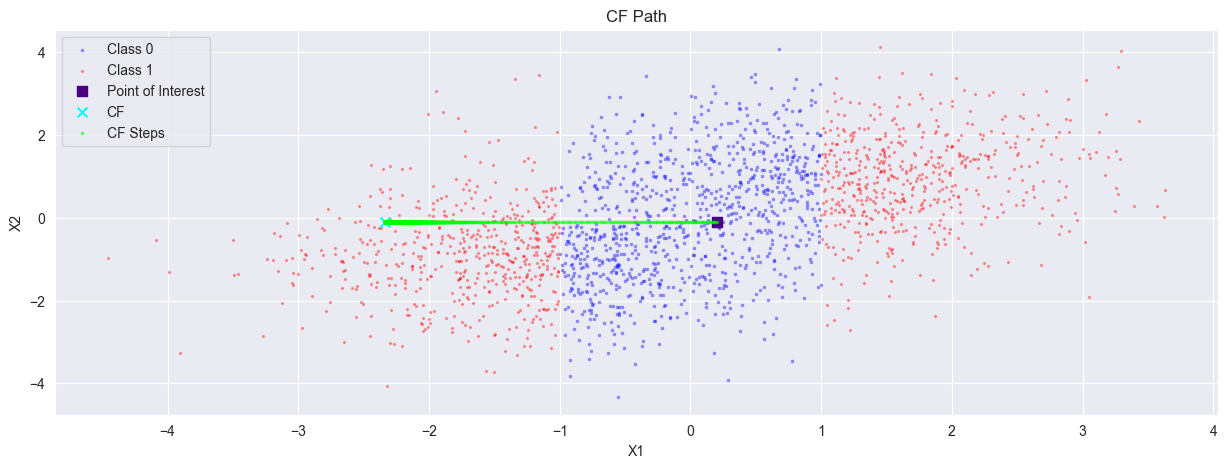

In [500]:
visualize_cf_and_steps(cf_feasable, cf_steps_feasable, points, y_pred_ensemble_points)

In [501]:
cf_feasable, cf_connected

(tensor([[-2.3381, -0.1000]]), tensor([[-2.4184, -0.1000]]))